## Calories Burnt Prediction using Muiltiple Algorithms in Scikit-Learn

### 1. Importing Libraries

In [30]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

### 2. Laoding Dataset

In [31]:
url_1 = "https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/56-Calories%20Burnt%20Prediction/exercise.csv"

In [32]:
url_2 = "https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/56-Calories%20Burnt%20Prediction/calories.csv"

In [33]:
df1 = df = pd.read_csv(url_1)
df1.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [34]:
df2 = pd.read_csv(url_2)
df2.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [35]:
df = pd.merge(df1, df2, on='User_ID')
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


### 3. Data Preprocessing

In [36]:
df.shape

(15000, 9)

In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
User_ID,15000.0,1.497736e+07,2.872851e+06,10001159.0,12474190.75,14997285.0,17449278.75,19999647.0
Age,15000.0,4.278980e+01,1.698026e+01,20.0,28.00,39.0,56.00,79.0
Height,15000.0,1.744651e+02,1.425811e+01,123.0,164.00,175.0,185.00,222.0
Weight,15000.0,7.496687e+01,1.503566e+01,36.0,63.00,74.0,87.00,132.0
Duration,15000.0,1.553060e+01,8.319203e+00,1.0,8.00,16.0,23.00,30.0
Heart_Rate,15000.0,9.551853e+01,9.583328e+00,67.0,88.00,96.0,103.00,128.0
Body_Temp,15000.0,4.002545e+01,7.792299e-01,37.1,39.60,40.2,40.60,41.5
Calories,15000.0,8.953953e+01,6.245698e+01,1.0,35.00,79.0,138.00,314.0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [39]:
df.isnull().sum()

,0
User_ID,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


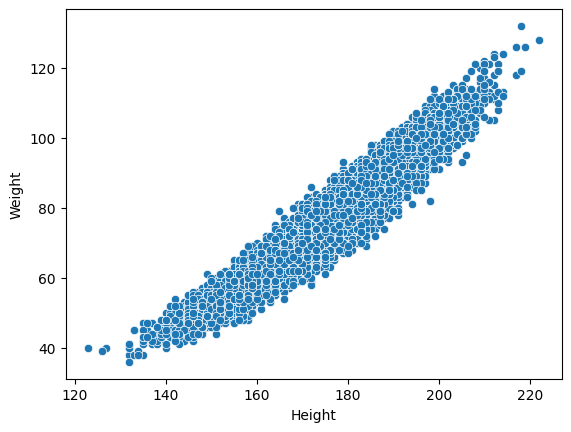

In [40]:
sns.scatterplot(x='Height', y='Weight', data=df) 
plt.show()

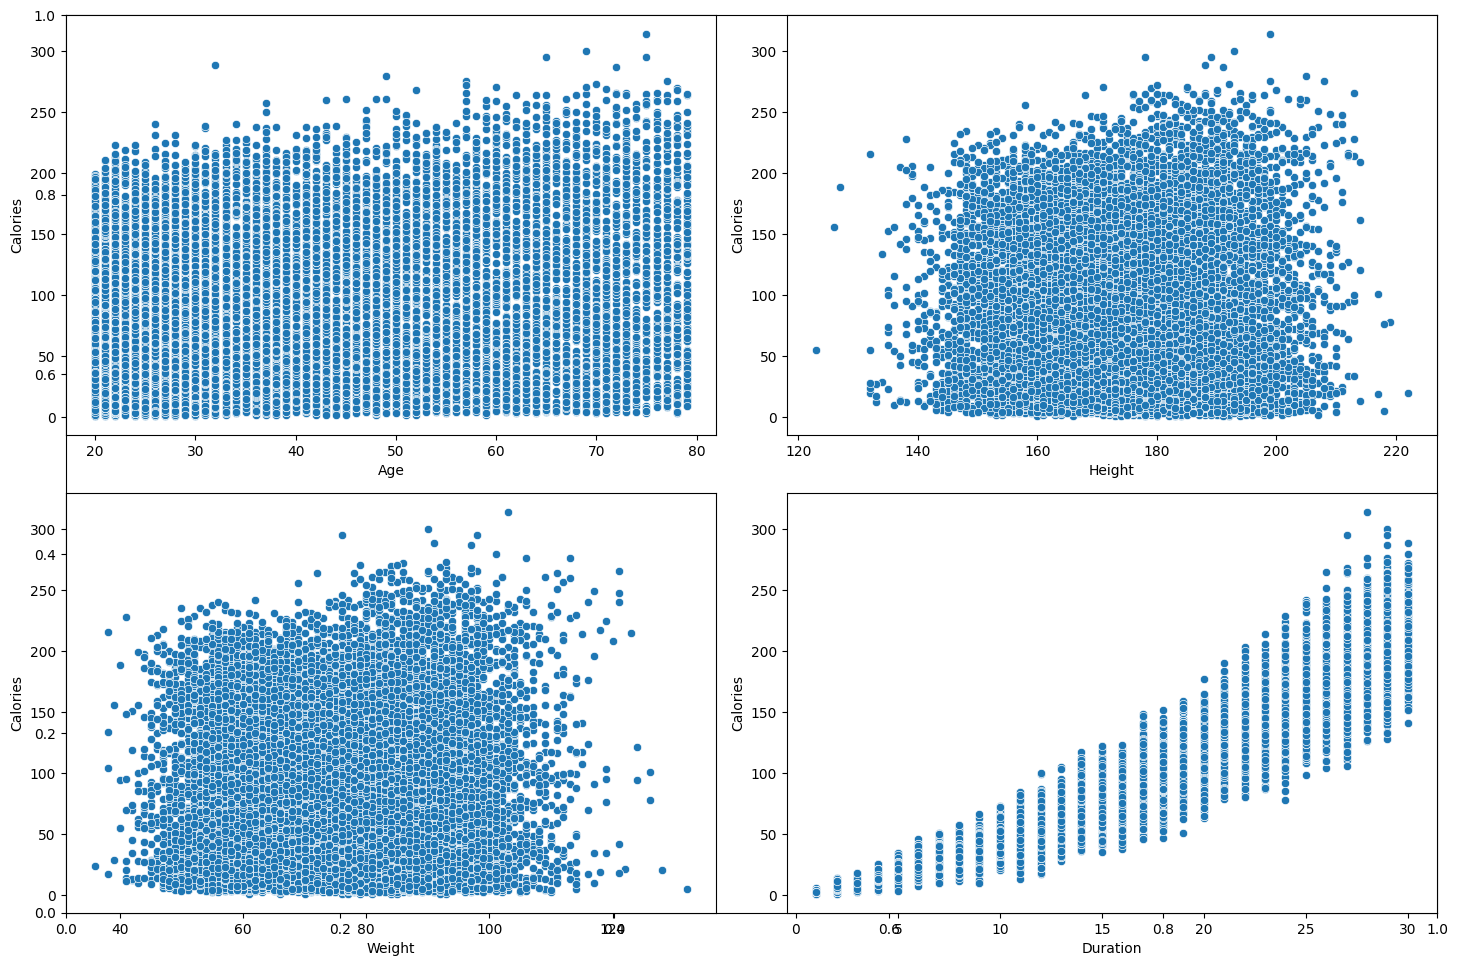

In [41]:
features = ['Age', 'Height', 'Weight', 'Duration']

plt.subplots(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    x = df.sample(1000)
    sns.scatterplot(x=col, y='Calories', data=df)
plt.tight_layout()
plt.show()

/tmp/ipykernel_18057/3787651138.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
/tmp/ipykernel_18057/3787651138.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
/tmp/ipykernel_18057/3787651138.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed i

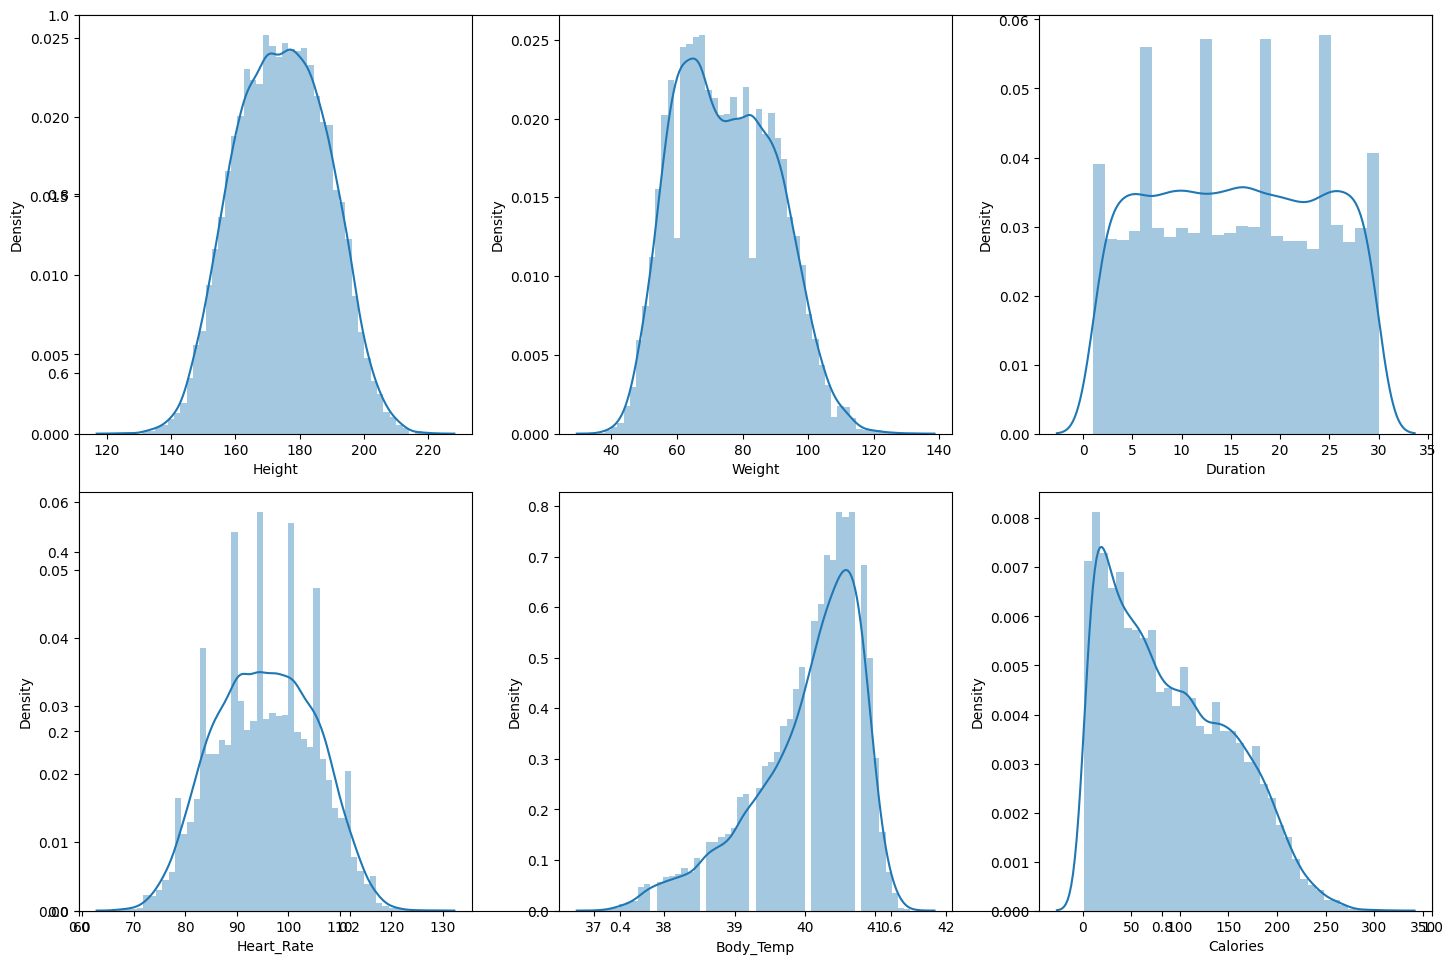

In [43]:
features = df.select_dtypes(include='float').columns

plt.subplots(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    sns.distplot(df[col])
plt.tight_layout()
plt.show()

In [44]:
df.replace({'male': 0, 'female': 1},
           inplace=True)
df.head()

/tmp/ipykernel_18057/2131168310.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'male': 0, 'female': 1},


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0


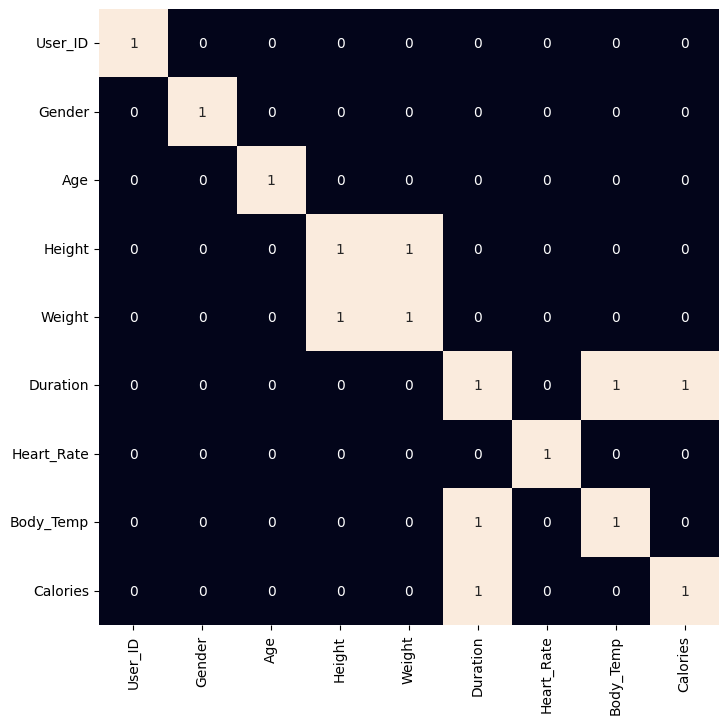

In [46]:
plt.figure(figsize=(8, 8))
sns.heatmap(df.corr() > 0.9,
           annot=True,
           cbar=False)
plt.show()

In [47]:
to_remove = ['Weight', 'Duration']
df.drop(to_remove, axis=1, inplace=True)

In [49]:
from sklearn.model_selection import train_test_split

X = df.drop(['User_ID', 'Calories'], axis=1)
y = df['Calories'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=22)
X_train.shape, X_test.shape

((13500, 5), (1500, 5))

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 4. Build and Fit the Models

In [52]:
from sklearn.metrics import mean_absolute_error as mae
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor

models = [LinearRegression(), XGBRegressor(),
          Lasso(), RandomForestRegressor(), Ridge()]

for i in range(5):
    models[i].fit(X_train, y_train)

    print(f'{models[i]} : ')

    train_preds = models[i].predict(X_train)
    print('Training Error : ', mae(y_train, train_preds))

    val_preds = models[i].predict(X_test)
    print('Validation Error : ', mae(y_test, val_preds))
    print()

LinearRegression() : 
Training Error :  17.893463692619434
Validation Error :  18.007896272831253

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...) : 
Training Error :  7.89463304294701
Validation Error :  10.12050432946533

Lasso() : 
Training Error :  17.915089584958036
Validation Error :  17.995

### 5. Make Prediction

In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

# exact training columns
feature_names = X.columns.tolist()

model_dict = {
    "Linear Regression": models[0],
    "XGBRegressor": models[1],
    "Lasso": models[2],
    "Random Forest Regressor": models[3],
    "Ridge": models[4]
}

model_dropdown = widgets.Dropdown(
    options=list(model_dict.keys()),
    description='Model:'
)

# make widgets using the REAL training column names
input_widgets = {}

for col in feature_names:
    if col.lower() == "gender":
        input_widgets[col] = widgets.Dropdown(
            options=[0, 1],
            value=0,
            description=f'{col}:'
        )
    else:
        input_widgets[col] = widgets.FloatText(
            value=0.0,
            description=f'{col}:'
        )

predict_button = widgets.Button(
    description='Predict',
    button_style='success'
)

output_box = widgets.Output()

def predict_calories(b):
    with output_box:
        clear_output()

        # collect values in EXACT same column order
        row = {col: input_widgets[col].value for col in feature_names}
        input_df = pd.DataFrame([row], columns=feature_names)

        # transform with the same scaler
        input_scaled = scaler.transform(input_df)

        # predict
        selected_model = model_dict[model_dropdown.value]
        prediction = selected_model.predict(input_scaled)[0]

        print(f"Selected Model: {model_dropdown.value}")
        print(f"Predicted Calories: {prediction:.2f}")

predict_button.on_click(predict_calories)

display(widgets.VBox(
    [model_dropdown] +
    [input_widgets[col] for col in feature_names] +
    [predict_button, output_box]
))

### 6. Evaluate the Models

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_names = ['Linear', 'XGB', 'Lasso', 'RF', 'Ridge']

mae_list = []
rmse_list = []
r2_list = []

for i, model in enumerate(models):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    mae_list.append(mae)
    rmse_list.append(rmse)
    r2_list.append(r2)

    print(f"\n{model_names[i]}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)


Linear
MAE: 18.007896272831253
RMSE: 22.821565648164427
R2: 0.8630172473732577

XGB
MAE: 10.12050432946533
RMSE: 14.289741473512251
R2: 0.9462938820131509

Lasso
MAE: 17.995033362288662
RMSE: 22.840284531218156
R2: 0.8627924410855803

RF
MAE: 10.438466071428572
RMSE: 14.781478995952158
R2: 0.942534022380381

Ridge
MAE: 18.00781790803129
RMSE: 22.82137159558788
R2: 0.8630195769016946


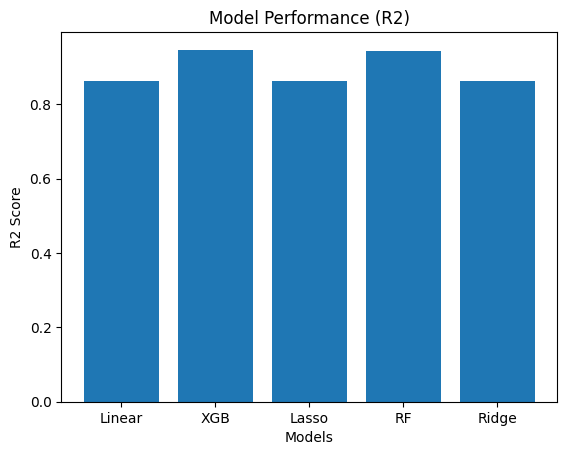

In [60]:
plt.figure()
plt.bar(model_names, r2_list)

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Performance (R2)")

plt.show()

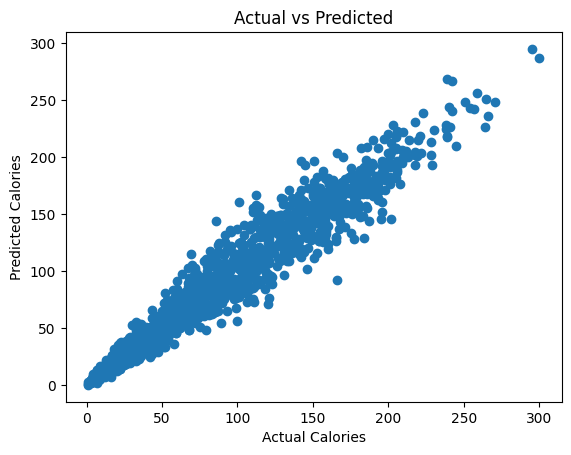

In [61]:
plt.figure()

y_pred = models[1].predict(X_test)  # choose best model (e.g., XGB)

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted")

plt.show()

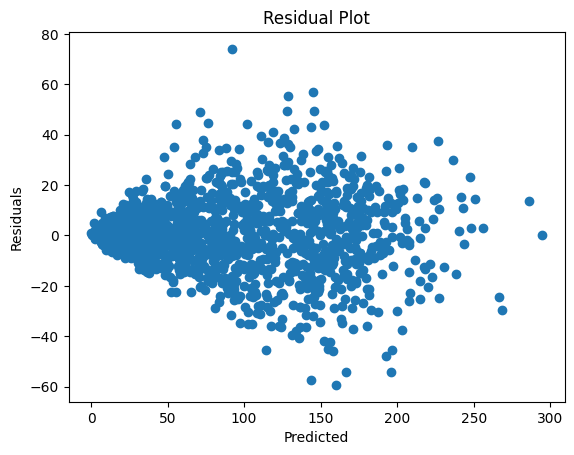

In [62]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()